<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/Q1136017_set_exercise_part2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SET EXERCISE DETAILS:
3. Load the dataset into your workspace, using the following link:
https://drive.google.com/file/d/1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn/view?usp=sharing
Choose an appropriate regression model, train and evaluate it.
Identify the underlying trends in the data

# Exploratory Data Analysis

## Import the libraries

In [17]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Upload the datasets

In [18]:
file_id = '1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

data = pd.read_csv(url)
data.head(10)

,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910
5,2.189355,8.786154
6,2.623489,6.818684
7,1.867776,8.895407
8,2.333211,8.346151
9,0.066760,0.543782


## Check for the rows and columns

In [19]:
# Print number of rows and columns
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 1000, Columns: 2


## Check the data types

In [20]:
data.dtypes

,0
t,float64
f(t),float64


## check for missing values

In [21]:
# Numeric count of missing values
print("--- Missing Values Breakdown ---")
print(data.isnull().sum())

--- Missing Values Breakdown ---
t       0
f(t)    0
dtype: int64


### check for symbols in the data

In [22]:
# Check for missing values per column
print("--- Missing Values Count ---")
print(data.isnull().sum())



--- Missing Values Count ---
t       0
f(t)    0
dtype: int64


## statistical summary

In [23]:
# Check for basic statistics and extreme value gaps
print(" Statistical Summary")
print(data.describe())

# Check for duplicate rows
print(f"\nDuplicate rows: {data.duplicated().sum()}")

 Statistical Summary
                 t         f(t)
count  1000.000000  1000.000000
mean      0.029528   276.432619
std       2.912450   490.620460
min      -4.981509     0.000152
25%      -2.571579     3.796317
50%       0.050400     8.999929
75%       2.644340   320.386458
max       4.989894  2092.282079

Duplicate rows: 0


## check for outliers

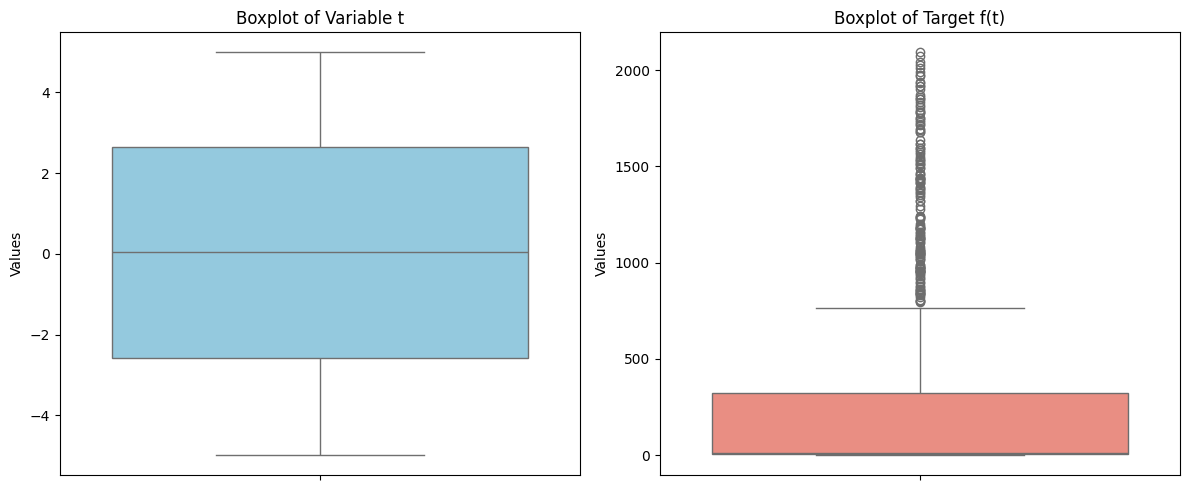

In [24]:
# Create side-by-side boxplots for t and f(t)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for t
sns.boxplot(data=data, y='t', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Variable t')
axes[0].set_ylabel('Values')

# Boxplot for f(t)
sns.boxplot(data=data, y='f(t)', ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Target f(t)')
axes[1].set_ylabel('Values')

plt.tight_layout()
plt.show()

## Check for duplicates

In [25]:
# Count total duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

# Display the duplicate rows if they exist
if duplicate_count > 0:
    print("\n--- Duplicate Rows Found ---")
    print(data[data.duplicated(keep=False)])
else:
    print("\nNo duplicate entries found. Every row is unique.")

Total Duplicate Rows: 0

No duplicate entries found. Every row is unique.


# Statistical analysis of the data

In [26]:
# Statistical analysis of the CLEANED data
data.describe()

,t,f(t)
count,1000.000000,1000.000000
mean,0.029528,276.432619
std,2.912450,490.620460
min,-4.981509,0.000152
25%,-2.571579,3.796317
50%,0.050400,8.999929
75%,2.644340,320.386458
max,4.989894,2092.282079


## Check for skewness

--- Skewness Values ---
Skewness of t:    -0.0147
Skewness of f(t): 1.9366



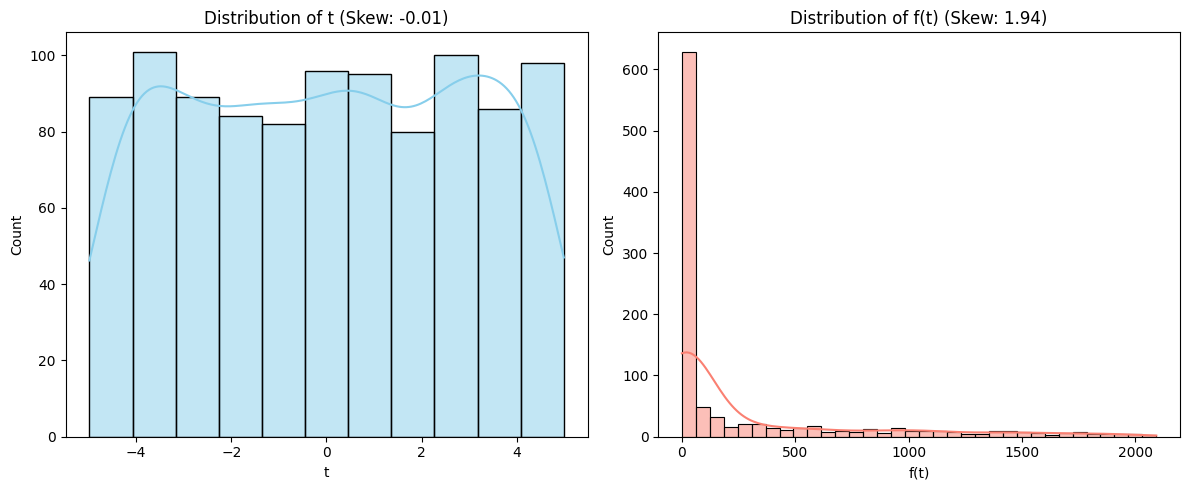

In [27]:
# Calculate numerical skewness values
t_skew = data['t'].skew()
ft_skew = data['f(t)'].skew()

print("--- Skewness Values ---")
print(f"Skewness of t:    {t_skew:.4f}")
print(f"Skewness of f(t): {ft_skew:.4f}\n")

# Plot the distribution curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data, x='t', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Distribution of t (Skew: {t_skew:.2f})')

sns.histplot(data=data, x='f(t)', kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f'Distribution of f(t) (Skew: {ft_skew:.2f})')

plt.tight_layout()
plt.show()

# Univariate analysis

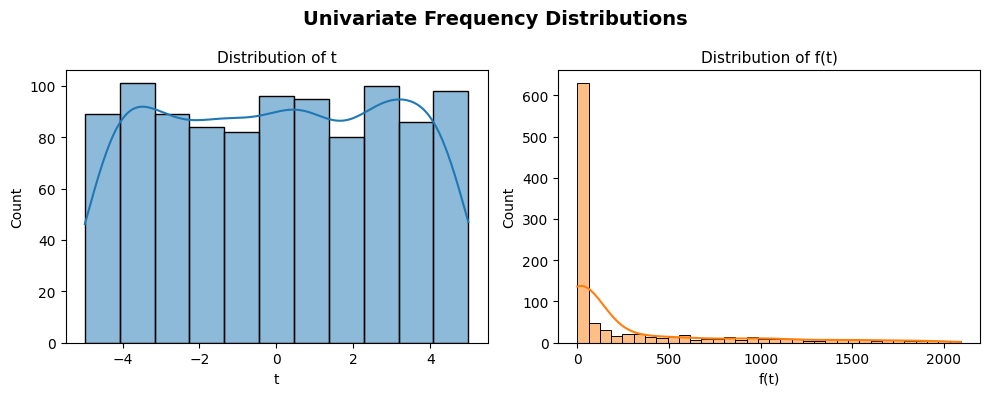

In [28]:
# Map the variables to their grid subplot positions
col_dict = {"t": 1, "f(t)": 2}
colors = ["#1f77b4", "#ff7f0e"]

plt.figure(figsize=(10, 4))

plt.suptitle("Univariate Frequency Distributions", fontsize=14, fontweight='bold', y=0.98)

for idx, (variable, position) in enumerate(col_dict.items()):
    plt.subplot(1, 2, position)
    sns.histplot(data[variable], kde=True, color=colors[idx])
    plt.title(f"Distribution of {variable}", fontsize=11)
    plt.ylabel("Count")
    plt.xlabel(variable)

plt.tight_layout()
plt.show()

# Bivariate Analysis

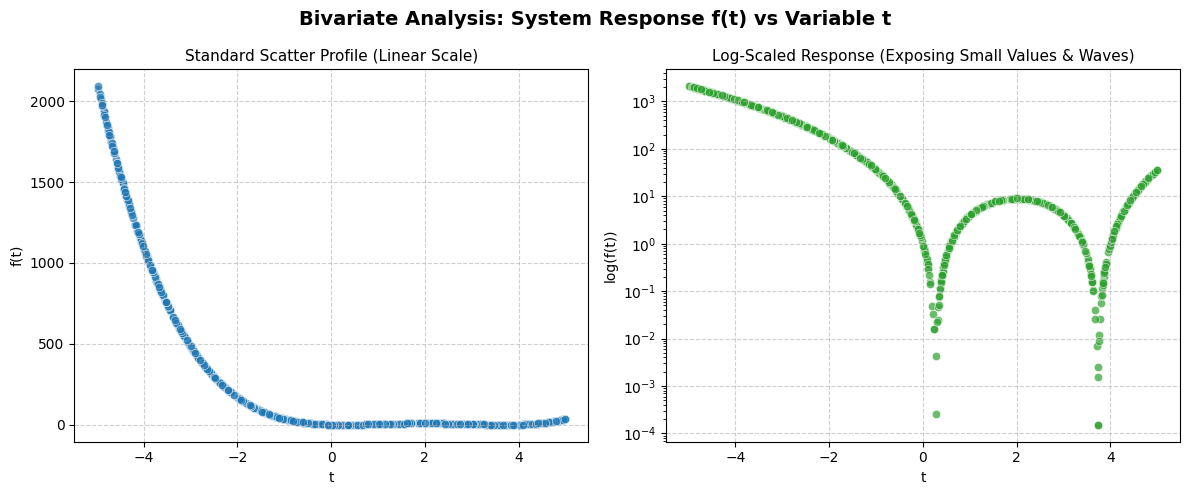

In [29]:
# Layout Config (1 Row, 2 Subplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.suptitle("Bivariate Analysis: System Response f(t) vs Variable t", fontsize=14, fontweight="bold", y=0.98)

# 1. Standard Scatter Profile
sns.scatterplot(data=data, x='t', y='f(t)', alpha=0.7, color='#1f77b4', ax=axes[0])
axes[0].set_title("Standard Scatter Profile (Linear Scale)", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. Log-Scaled Response
sns.scatterplot(data=data, x='t', y='f(t)', alpha=0.7, color='#2ca02c', ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_ylabel("log(f(t))")
axes[1].set_title("Log-Scaled Response (Exposing Small Values & Waves)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Multivariate analsis



--- Correlation Matrix Values ---
             t      f(t)
t     1.000000 -0.750757
f(t) -0.750757  1.000000


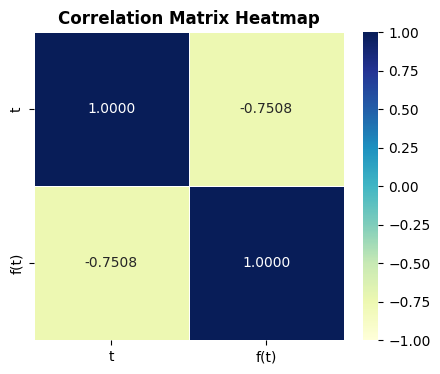

In [30]:
# Calculate the correlation matrix
corr_matrix = data[['t', 'f(t)']].corr()
print("--- Correlation Matrix Values ---")
print(corr_matrix)

# Plot the heatmap using a Blue-Green palette
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=12, fontweight='bold')
plt.show()

# Model selection and comparison

--- Performance Comparison ---
        Model     RMSE  R2 Score
Random Forest 3.698934  0.999947
      XGBoost 9.825061  0.999625


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


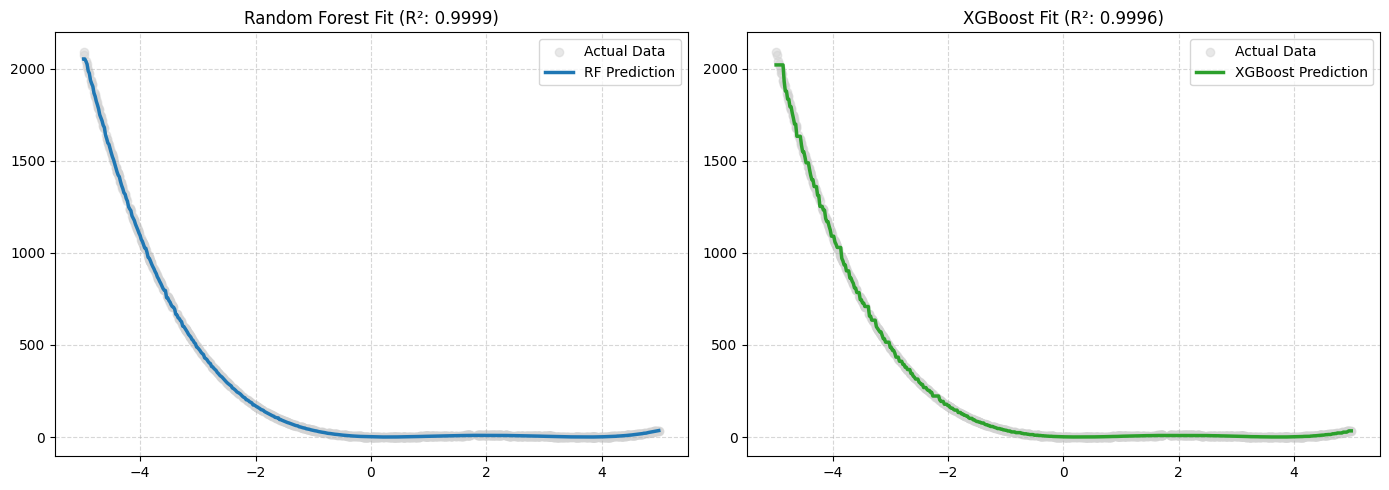

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare data structures
X = data[['t']]
y = data['f(t)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and train models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 3. Evaluate models on the test set
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

metrics = {
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_pred)), np.sqrt(mean_squared_error(y_test, xgb_pred))],
    "R2 Score": [r2_score(y_test, rf_pred), r2_score(y_test, xgb_pred)]
}
print("--- Performance Comparison ---")
print(pd.DataFrame(metrics).to_string(index=False))

# 4. Generate smooth prediction visualization paths
X_smooth = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
rf_smooth = rf_model.predict(X_smooth)
xgb_smooth = xgb_model.predict(X_smooth)

# 5. Plot Comparison Layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Subplot
axes[0].scatter(X, y, color='lightgray', alpha=0.5, label='Actual Data')
axes[0].plot(X_smooth, rf_smooth, color='#1f77b4', linewidth=2.5, label='RF Prediction')
axes[0].set_title(f"Random Forest Fit (R²: {metrics['R2 Score'][0]:.4f})")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# XGBoost Subplot
axes[1].scatter(X, y, color='lightgray', alpha=0.5, label='Actual Data')
axes[1].plot(X_smooth, xgb_smooth, color='#2ca02c', linewidth=2.5, label='XGBoost Prediction')
axes[1].set_title(f"XGBoost Fit (R²: {metrics['R2 Score'][1]:.4f})")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()